Sentence: Hello!
Planned gestures: [('emphatic', 1.0), ('hands_up', 1.2)]


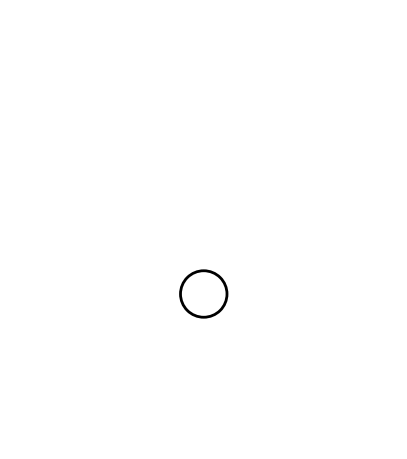

Sentence: Can you show me that?
Planned gestures: [('head_tilt', 1.4), ('point', 1.5)]


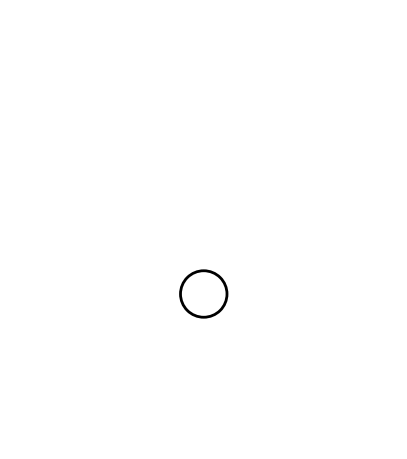

Sentence: Thanks very much
Planned gestures: [('bow', 1.6)]


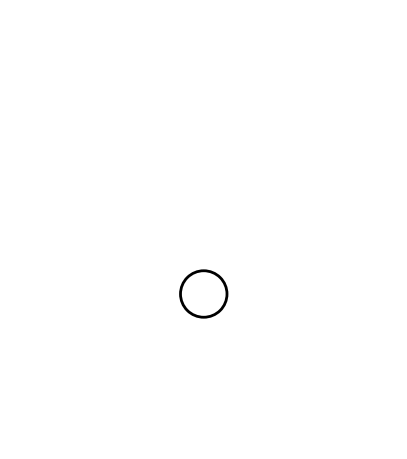

Sentence: Yes, that's correct.
Planned gestures: [('nod', 1.2)]


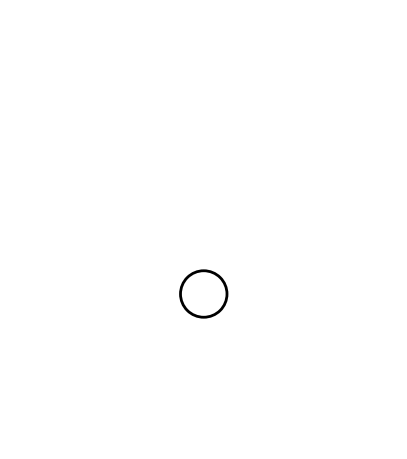

Sentence: No, not now.
Planned gestures: [('shake', 1.2)]


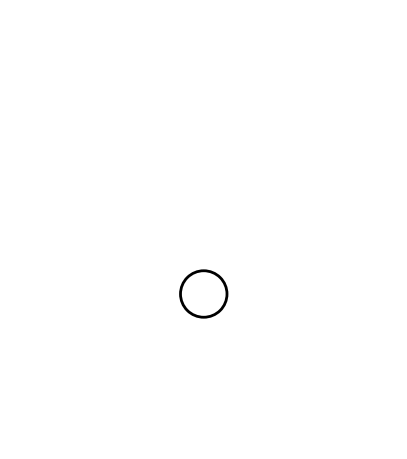

Sentence: Look over there
Planned gestures: [('point', 1.5)]


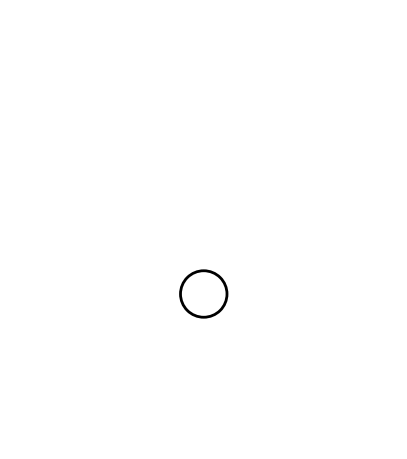

Sentence: I LOVE this!
Planned gestures: [('emphatic', 1.0), ('hands_up', 1.2)]


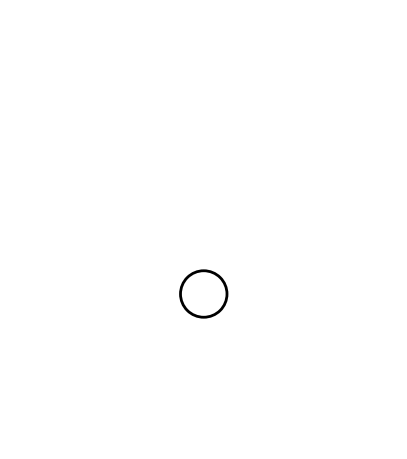

Sentence: Can you point to the blue one?
Planned gestures: [('head_tilt', 1.4), ('point', 1.5)]


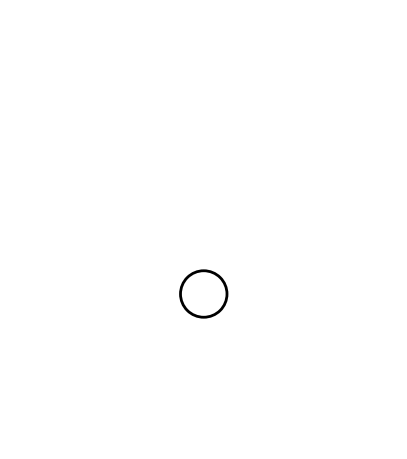

Sentence: This work is very hard for Me.
Planned gestures: [('point', 1.5)]


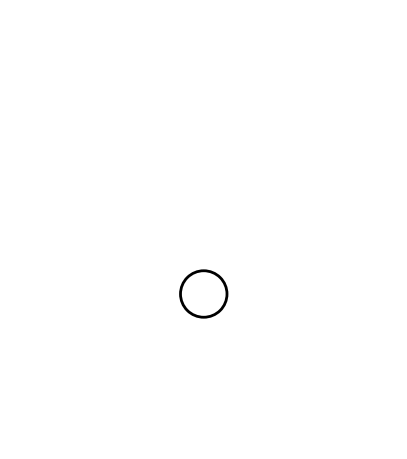

In [2]:
# sentence_to_gesture.py
# Simple demo: map sentences to simple gestures and animate a stick-figure performing them.
# Dependencies: matplotlib, numpy
# Run: python sentence_to_gesture.py

import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -------------------------
# Gesture definitions & mapping rules
# -------------------------
# Available gesture primitives:
# - 'idle'       : small breathing
# - 'nod'        : yes (vertical head)
# - 'shake'      : no (horizontal head)
# - 'wave'       : hand wave (right arm)
# - 'point'      : point forward (right arm extended)
# - 'hands_up'   : raised arms (emphasis / excitement)
# - 'bow'        : slight forward torso (thanks/apology)
# - 'head_tilt'  : tilt head (question)
# - 'emphatic'   : quick arm thump (exclamation emphasis)

# Basic lexicons
WAVE_WORDS = {'hello', 'hi', 'hey', 'hiya', 'greetings'}
THANKS_WORDS = {'thanks', 'thank', 'thankyou', 'thank you', 'thx', 'ty'}
YES_WORDS = {'yes', 'yeah', 'yep', 'sure', 'yup', 'correct', 'right'}
NO_WORDS = {'no', 'nope', 'nah'}
POINT_WORDS = {'this', 'that', 'over', 'there', 'see', 'look'}
QUESTION_WORDS = {'who','what','when','where','why','how'}
EMPHASIS_PUNCT = {'!'}
# detect verbs (very simple heuristic)
POINT_VERBS = {'show','point','indicate','look'}

def preprocess(text):
    t = text.lower().strip()
    t = re.sub(r'[^\w\s?!)\(\]\[]', '', t)  # remove punctuation except ? !
    return t

def pick_gestures(sentence):
    """
    Return a list of (gesture, duration_sec) in order chosen for sentence.
    This is heuristic: picks a main gesture and some short supporting gestures.
    """
    s_raw = sentence.strip()
    s = preprocess(sentence)
    tokens = set(s.split())

    gestures = []

    # priority rules
    if any(w in tokens for w in WAVE_WORDS) and len(tokens) <= 4:
        gestures.append(('wave', 2.0))
    if any(w in tokens for w in THANKS_WORDS):
        gestures.append(('bow', 1.6))
    if any(w in tokens for w in YES_WORDS):
        gestures.append(('nod', 1.2))
    if any(w in tokens for w in NO_WORDS):
        gestures.append(('shake', 1.2))

    # question: question mark OR wh-word
    if '?' in s_raw or any(w in tokens for w in QUESTION_WORDS):
        gestures.append(('head_tilt', 1.4))

    # emphasis: exclamation or ALL CAPS words
    if any(p in s_raw for p in EMPHASIS_PUNCT) or any(w.isupper() and len(w) > 1 for w in sentence.split()):
        gestures.append(('emphatic', 1.0))
        # also raise hands for excitement
        gestures.append(('hands_up', 1.2))

    # pointing: presence of point verbs/words
    if any(w in tokens for w in POINT_VERBS) or any(w in tokens for w in POINT_WORDS):
        gestures.append(('point', 1.5))

    # fallback: if nothing selected, small idle + maybe nod or hands_up for short exclamations
    if not gestures:
        # choose subtle gesture based on sentence sentiment heuristics (very simple)
        if any(c in s_raw for c in ['!', 'great', 'awesome', 'love', 'yay']):
            gestures.append(('hands_up', 1.5))
        elif len(s.split()) > 3:
            gestures.append(('nod', 1.2))
        else:
            gestures.append(('idle', 2.0))

    # compress duplicates and keep reasonable ordering (head gestures before arm gestures)
    # prefer head gestures early
    head = [g for g in gestures if g[0] in ('nod','shake','head_tilt','bow')]
    arms = [g for g in gestures if g[0] in ('wave','point','hands_up','emphatic')]
    idle = [g for g in gestures if g[0]=='idle']
    ordered = head + arms + idle
    # cap total duration
    max_total = 6.0
    total = 0.0
    out = []
    for g,d in ordered:
        if total + d > max_total:
            d = max(0.6, max_total - total)
        out.append((g,d))
        total += d
        if total >= max_total:
            break
    return out

# -------------------------
# Simple stick-figure renderer
# -------------------------
class StickFigure:
    def __init__(self, ax):
        self.ax = ax
        # body points (x,y)
        self.head_center = np.array([0.0, 1.6])
        self.torso_top = np.array([0.0, 1.4])
        self.torso_bottom = np.array([0.0, 0.6])
        self.left_shoulder = np.array([-0.2, 1.3])
        self.right_shoulder = np.array([0.2, 1.3])
        self.left_hand = self.left_shoulder + np.array([-0.5, -0.3])
        self.right_hand = self.right_shoulder + np.array([0.5, -0.3])
        self.left_hip = np.array([-0.15, 0.6])
        self.right_hip = np.array([0.15, 0.6])
        self.left_foot = self.left_hip + np.array([-0.15, -0.7])
        self.right_foot = self.right_hip + np.array([0.15, -0.7])

        # artists
        self.lines = {}
        # torso
        self.lines['torso'], = ax.plot([], [], lw=3, solid_capstyle='round')
        # head (circle)
        self.lines['head'] = plt.Circle((0,0), 0.18, fill=False, lw=2)
        ax.add_patch(self.lines['head'])
        # arms
        self.lines['left_arm'], = ax.plot([], [], lw=3, solid_capstyle='round')
        self.lines['right_arm'], = ax.plot([], [], lw=3, solid_capstyle='round')
        # legs
        self.lines['left_leg'], = ax.plot([], [], lw=3, solid_capstyle='round')
        self.lines['right_leg'], = ax.plot([], [], lw=3, solid_capstyle='round')
        # eyes (for head tilt / nod)
        self.left_eye = plt.Line2D([], [], lw=2)
        self.right_eye = plt.Line2D([], [], lw=2)
        ax.add_line(self.left_eye)
        ax.add_line(self.right_eye)

    def set_limits(self):
        self.ax.set_xlim(-1.5, 1.5)
        self.ax.set_ylim(-1.2, 2.2)
        self.ax.set_aspect('equal')
        self.ax.axis('off')

    def draw(self, pose):
        """
        pose: dict containing positions or offsets for parts:
         - head_offset: (dx,dy) for head center
         - head_angle: in radians (tilt)
         - right_hand_pos: absolute pos np.array([x,y]) or None
         - left_hand_pos: same
         - torso_forward: scalar (for bow)
        """
        hc = self.head_center + pose.get('head_offset', np.array([0.0,0.0]))
        torso_top = self.torso_top + np.array([0.0, pose.get('torso_forward',0.0)])
        torso_bottom = self.torso_bottom + np.array([0.0, pose.get('torso_forward',0.0)])
        right_sh = self.right_shoulder + np.array([0.0, pose.get('torso_forward',0.0)])
        left_sh = self.left_shoulder + np.array([0.0, pose.get('torso_forward',0.0)])

        # arms: compute hand positions
        rh_pos = pose.get('right_hand_pos', self.right_hand)
        lh_pos = pose.get('left_hand_pos', self.left_hand)

        # torso line
        self.lines['torso'].set_data([torso_top[0], torso_bottom[0]], [torso_top[1], torso_bottom[1]])
        # head circle
        self.lines['head'].center = (hc[0], hc[1])
        # eyes: small marks relative to head center, rotated by head_angle
        angle = pose.get('head_angle', 0.0)
        # eye offsets
        e_off = 0.06
        left_eye_pos = np.array([-e_off, 0.03])
        right_eye_pos = np.array([e_off, 0.03])
        # rotate by angle
        rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
        left_eye_world = hc + rot.dot(left_eye_pos)
        right_eye_world = hc + rot.dot(right_eye_pos)
        self.left_eye.set_data([left_eye_world[0]], [left_eye_world[1]])
        self.right_eye.set_data([right_eye_world[0]], [right_eye_world[1]])
        # arms
        self.lines['left_arm'].set_data([left_sh[0], lh_pos[0]], [left_sh[1], lh_pos[1]])
        self.lines['right_arm'].set_data([right_sh[0], rh_pos[0]], [right_sh[1], rh_pos[1]])
        # legs (static)
        self.lines['left_leg'].set_data([self.left_hip[0], self.left_foot[0]], [self.left_hip[1], self.left_foot[1]])
        self.lines['right_leg'].set_data([self.right_hip[0], self.right_foot[0]], [self.right_hip[1], self.right_foot[1]])

# -------------------------
# Animation primitives (produce pose at time t in [0,1])
# each returns a pose dict
# -------------------------
def idle_pose(t):
    # breathing: slight up/down head
    dy = 0.02 * np.sin(2*np.pi*t)
    return {'head_offset': np.array([0.0, dy]), 'head_angle': 0.0}

def nod_pose(t):
    # nodding: small vertical oscillation (t in seconds -> normalized)
    angle = 0.5 * np.sin(4*np.pi*t)  # tilt a bit
    offset = 0.08 * np.sin(2*np.pi*t)
    return {'head_offset': np.array([0.0, offset]), 'head_angle': angle}

def shake_pose(t):
    # horizontal head shake
    offset_x = 0.12 * np.sin(4*np.pi*t)
    return {'head_offset': np.array([offset_x, 0.0]), 'head_angle': 0.15 * np.sin(4*np.pi*t)}

def head_tilt_pose(t):
    angle = 0.35 * np.sin(2*np.pi*t)
    return {'head_offset': np.array([0.0, 0.0]), 'head_angle': angle}

def wave_pose(t):
    # wave: right arm moves up and oscillates
    # t in [0,1]
    # hand path: arc up then wave (sine)
    raise_phase = min(1.0, t*2.0)
    hand_x = 0.2 + 0.5*raise_phase
    hand_y = 1.0 + 0.4*raise_phase
    # waving oscillation when raised
    if t > 0.5:
        w = 0.15 * np.sin(12*np.pi*(t-0.5))
        hand_x += w
    return {'right_hand_pos': np.array([hand_x, hand_y]), 'head_offset': np.array([0.0, 0.0])}

def point_pose(t):
    # right arm extends forward (x increases), small retraction
    x = 0.6 + 0.1 * np.sin(2*np.pi*t)
    y = 0.85 + 0.05*np.cos(2*np.pi*t)
    return {'right_hand_pos': np.array([x, y])}

def hands_up_pose(t):
    # both hands raised above head
    left = np.array([-0.4, 1.55]) + np.array([0.08*np.sin(6*np.pi*t), 0.04*np.cos(6*np.pi*t)])
    right = np.array([0.4, 1.55]) + np.array([0.08*np.sin(6*np.pi*t+0.5), 0.04*np.cos(6*np.pi*t+0.5)])
    return {'right_hand_pos': right, 'left_hand_pos': left, 'head_offset': np.array([0.0, 0.0])}

def bow_pose(t):
    # torso leans forward and head goes down slightly
    forward = -0.12 * (0.5 + 0.5*np.cos(np.pi*t))  # forward peak in middle
    head_dy = -0.15 * (0.5 + 0.5*np.cos(np.pi*t))
    return {'torso_forward': forward, 'head_offset': np.array([0.0, head_dy]), 'head_angle': 0.0}

def emphatic_pose(t):
    # quick arm punch / thump to the side
    x = 0.25 + 0.5*(0.5 - 0.5*np.cos(6*np.pi*t))
    y = 0.9
    return {'right_hand_pos': np.array([x,y]), 'head_offset': np.array([0.0, 0.05*np.sin(4*np.pi*t)])}

# map name -> function
POSE_FUN = {
    'idle': idle_pose,
    'nod': nod_pose,
    'shake': shake_pose,
    'head_tilt': head_tilt_pose,
    'wave': wave_pose,
    'point': point_pose,
    'hands_up': hands_up_pose,
    'bow': bow_pose,
    'emphatic': emphatic_pose
}

# -------------------------
# High-level animation runner
# -------------------------
def animate_gesture_sequence(sentence, fps=30):
    gestures = pick_gestures(sentence)
    print("Sentence:", sentence)
    print("Planned gestures:", gestures)

    # build timeline: list of (gesture_name, frames)
    timeline = []
    total_frames = 0
    for name, dur in gestures:
        frames = max(1, int(fps * dur))
        timeline.append((name, frames))
        total_frames += frames

    fig, ax = plt.subplots(figsize=(5,6))
    sf = StickFigure(ax)
    sf.set_limits()

    # state for animation
    frame_idx = 0
    # flatten timeline into list mapping frame -> (gesture, local_t)
    frame_map = []
    for gname, nframes in timeline:
        for i in range(nframes):
            local_t = (i / max(1, nframes-1)) if nframes > 1 else 0.0
            frame_map.append((gname, local_t))
    # pad small idle at end
    for _ in range(int(fps*0.4)):
        frame_map.append(('idle', 0.0))

    def update(i):
        gname, local_t = frame_map[i]
        pose = POSE_FUN.get(gname, idle_pose)(local_t)
        sf.draw(pose)
        return list(sf.lines.values()) + [sf.left_eye, sf.right_eye]

    ani = FuncAnimation(fig, update, frames=len(frame_map), interval=1000/fps, blit=False, repeat=False)
    plt.show()

# -------------------------
# Demo / main
# -------------------------
if __name__ == "__main__":
    examples = [
        "Hello!",
        "Can you show me that?",
        "Thanks very much",
        "Yes, that's correct.",
        "No, not now.",
        "Look over there",
        "I LOVE this!",
        "Can you point to the blue one?"
    ]

    # animate examples one by one
    for s in examples:
        animate_gesture_sequence(s)

    # you can also enter your own
    while True:
        try:
            text = input("\nEnter a sentence (or 'quit' to exit): ").strip()
        except (EOFError, KeyboardInterrupt):
            break
        if not text or text.lower() in ('quit','exit'):
            break
        animate_gesture_sequence(text)
